In [1]:
import os
import mdtraj as md
from utility.Reporting import *
from utility.General import *
from utility.FileManipulations import *

## It all starts with a ligand...

**DrugBank ID** DB04829 \
**Name** Lysergic acid diethylamide\
**Groups** investigational, illicit


Debate continues over the nature and causes of chronic flashbacks. Explanations in terms of LSD physically remaining in the body for months or years after consumption have been discounted by experimental evidence. Some say HPPD is a manifestation of post-traumatic stress disorder, not related to the direct action of LSD on brain chemistry, and varies according to the susceptibility of the individual to the disorder. Many emotionally intense experiences can lead to flashbacks when a person is reminded acutely of the original experience. However, not all published case reports of chronic flashbacks appear to describe an anxious hyper-vigilant state reminiscent of post-traumatic stress disorder.

In [2]:
#obtained as the canonical smiles at https://www.rcsb.org/ligand/7LD
from openff.toolkit import Molecule
ligand = Molecule.from_smiles("COCO[C@H]1C[C@@H](C(=O)OC)[C@]2(C)CC[C@H]3C(=O)O[C@@H](C[C@]3(C)[C@H]2C1=O)c4cocc4")

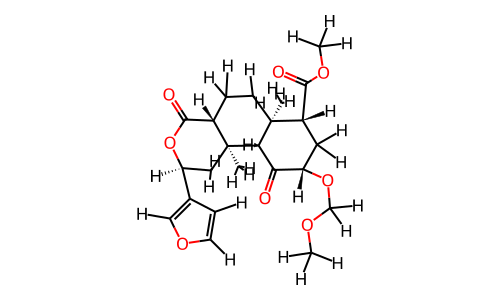

In [3]:
ligand

### Obtain Files from the RCSB

In this case I hvae 4 structures of the 5-HT2B receptor in complex with LSD

In [4]:
#All are 5HT2B with LSD - they are bound to different complexes
kor_cifs = ['test_data/raw_RCSB/8DZP.cif']

# lsd_cifs = ['test_data/raw_RCSB/5TVN.cif', #https://www.rcsb.org/structure/5TVN
#             'test_data/raw_RCSB/7SRQ.cif', #https://www.rcsb.org/structure/7SRQ
#             'test_data/raw_RCSB/7SRR.cif', #https://www.rcsb.org/structure/7SRR
#             'test_data/raw_RCSB/7SRS.cif'] #https://www.rcsb.org/structure/7SRS

#The sequence is the same for all of these, load it.  Obtained from UniProt (https://www.uniprot.org/uniprotkb/P41595/entry#sequences)
#WARNING - Assume that the uniprot sequence is in a file that has only two lines, and that the sequence is the second line
# with open('test_data/raw_RCSB/htr2b.uniprot_seq.txt', 'r') as f:
#     htr2b_seq = f.read().split('\n')[1]

In [5]:
for lsdcif in kor_cifs:
    print(lsdcif)
    print(report_chain_information(md.load(lsdcif)))

test_data/raw_RCSB/8DZP.cif
2026-03-07 22:44:51.478627://Begin Reporting Chain Information
2026-03-07 22:44:51.478736://	chainID=A chainIndex=0 N_atoms=2160 N_residues=280
2026-03-07 22:44:51.478785://	Unique Residues in Chain ALA ARG ASN ASP CYS GLN GLU GLY HIS ILE LEU LYS MET PHE PRO SER THR TRP TYR VAL
2026-03-07 22:44:51.478848://	chainID=B chainIndex=1 N_atoms=1691 N_residues=214
2026-03-07 22:44:51.478885://	Unique Residues in Chain ALA ARG ASN ASP CYS GLN GLU GLY HIS ILE LEU LYS MET PHE PRO SER THR TRP TYR VAL
2026-03-07 22:44:51.478968://	chainID=C chainIndex=2 N_atoms=2593 N_residues=339
2026-03-07 22:44:51.479020://	Unique Residues in Chain ALA ARG ASN ASP CYS GLN GLU GLY HIS ILE LEU LYS MET PHE PRO SER THR TRP TYR VAL
2026-03-07 22:44:51.479037://	chainID=D chainIndex=3 N_atoms=399 N_residues=55
2026-03-07 22:44:51.479048://	Unique Residues in Chain ALA ARG ASN ASP CYS GLN GLU HIS ILE LEU LYS MET PHE PRO SER THR TYR VAL
2026-03-07 22:44:51.479120://	chainID=E chainIndex=4 N_

/home/exouser/miniconda3/envs/chimpss/lib/python3.12/site-packages/mdtraj/formats/pdbx/pdbx.py:183: UserWarning: Unlikely unit cell vectors detected in PDB file likely resulting from a dummy CRYST1 record. Discarding unit cell vectors.
  warnings.warn(


#### Now is a good time to visually analyze the CIFs in Chimera

**5TVN**: Chimera Report chain A for both, mdtraj reports chain index 0, and 1\
N-Term: GLU 41 (Could be Trimmed to GLY 51)\
C-Term: ARG 400\
Missing Loop: THR 197 - ASN 201\
Missing Loop: GLU 1049 - PRO 1056

**7SRQ**: Chimera reports chain R for both, mdtraj reports chain index 0, 2\
N-Term: TRP 56\
C-Term: TYR 394\
Missing Loop: PRO 160 - SER 168\
Missing Loop: ALA 243 - ALA 322

**7SRR**: Chimera reports chain R for both (R is 274 residues),\
    selection matches chains 4, 5 from mdtraj printing above \
N-Term: TRP 56\
C-Term: ILE 395\
Missing Loop: ALA 248 - THR 315

**7SRS**: Chimera report chain R, (289 res, 2234 atom),\
    selection matches index 2, 7 from print above\
N-Term: TRP 56\
C-Term: CYS 397\
Missing Loop: SER 251 - ARG 313

**8DZP** Chimera Report chain A (280 res),\
    mdtraj above gives 0, 5\
N-Term: ALA 57\
C-Term: ARG 339\
Missing Loop: ARG 202 - ASP 206


In [6]:
chains2keep = [{"protein":'chainid 0', "ligand": 'chainid 5'}]
# chains2keep = [{"protein":'chainid 0', "ligand": 'chainid 1'},
#                {"protein":'chainid 0', "ligand": 'chainid 2'},
#                {"protein":'chainid 4', "ligand": 'chainid 5'},
#                {"protein":'chainid 2', "ligand": 'chainid 7'}]

In [7]:
lsd_pdbs = [cif2pdb(lsdcif) for lsdcif in kor_cifs]

*** Open Babel Warning  in PerceiveBondOrders
  Failed to kekulize aromatic bonds in OBMol::PerceiveBondOrders (title is 8DZP)

1 molecule converted


In [8]:
working_direc = './Test_Work'

save_dir = os.path.join(working_direc, 'input_pdbs')
ensure_exists(save_dir)

#Review the output and set to true if good
should_save = True

for lsdcif, selection in zip(lsd_pdbs, chains2keep):
    print(lsdcif)
    name = os.path.basename(lsdcif).split('.')[0]
    rcsb = md.load(lsdcif)
    p_traj = slice_select(rcsb, selection['protein'])
    print(report_chain_information(p_traj))
    l_traj = slice_select(rcsb, selection['ligand'])
    print(report_chain_information(l_traj))
    comp_traj = slice_select(rcsb, f"{selection['protein']} or {selection['ligand']}")
    print(report_chain_information(comp_traj))

    if should_save:
        p_traj.save_pdb(os.path.join(save_dir, f"{name}_protein.mdtraj.pdb"))
        l_traj.save_pdb(os.path.join(save_dir, f"{name}_ligand.mdtraj.pdb"))
        #comp_traj.save_pdb(os.path.join(save_dir, f"{name}_complex.mdtraj.pdb"))

test_data/raw_RCSB/8DZP.obabel.pdb
2026-03-07 22:44:52.165310://Begin Reporting Chain Information
2026-03-07 22:44:52.165358://	chainID=A chainIndex=0 N_atoms=2160 N_residues=280
2026-03-07 22:44:52.165394://	Unique Residues in Chain ALA ARG ASN ASP CYS GLN GLU GLY HIS ILE LEU LYS MET PHE PRO SER THR TRP TYR VAL
2026-03-07 22:44:52.172725://Begin Reporting Chain Information
2026-03-07 22:44:52.172734://	chainID=F chainIndex=0 N_atoms=31 N_residues=1
2026-03-07 22:44:52.172739://	Unique Residues in Chain U99
2026-03-07 22:44:52.188408://Begin Reporting Chain Information
2026-03-07 22:44:52.188454://	chainID=A chainIndex=0 N_atoms=2160 N_residues=280
2026-03-07 22:44:52.188491://	Unique Residues in Chain ALA ARG ASN ASP CYS GLN GLU GLY HIS ILE LEU LYS MET PHE PRO SER THR TRP TYR VAL
2026-03-07 22:44:52.188494://	chainID=F chainIndex=1 N_atoms=31 N_residues=1
2026-03-07 22:44:52.188497://	Unique Residues in Chain U99


/home/exouser/miniconda3/envs/chimpss/lib/python3.12/site-packages/mdtraj/formats/pdb/pdbfile.py:214: UserWarning: Unlikely unit cell vectors detected in PDB file likely resulting from a dummy CRYST1 record. Discarding unit cell vectors.
  warnings.warn(


In [9]:
sorted(glob.glob('Test_Work/input_pdbs/*.pdb'))

['Test_Work/input_pdbs/5TVN_ligand.mdtraj.pdb',
 'Test_Work/input_pdbs/5TVN_protein.mdtraj.pdb',
 'Test_Work/input_pdbs/5TVN_protein_temp.pdb',
 'Test_Work/input_pdbs/7SRQ_ligand.mdtraj.pdb',
 'Test_Work/input_pdbs/7SRQ_protein.mdtraj.pdb',
 'Test_Work/input_pdbs/7SRR_ligand.mdtraj.pdb',
 'Test_Work/input_pdbs/7SRR_protein.mdtraj.pdb',
 'Test_Work/input_pdbs/7SRS_ligand.mdtraj.pdb',
 'Test_Work/input_pdbs/7SRS_protein.mdtraj.pdb',
 'Test_Work/input_pdbs/8DZP_ligand.mdtraj.pdb',
 'Test_Work/input_pdbs/8DZP_protein.mdtraj.pdb']

### Repair and Prep the Proteins

In [10]:
from RepairProtein.RepairProtein import RepairProtein

In [11]:
#alphafold3 = cif2pdb('test_data/alphafold3/fold_htr2b_model_0.cif')

In [12]:
oprk_seq = "MDSPIQIFRGEPGPTCAPSACLPPNSSAWFPGWAEPDSNGSAGSEDAQLEPAHISPAIPVIITAVYSVVFVVGLVGNSLVMFVIIRYTKMKTATNIYIFNLALADALVTTTMPFQSTVYLMNSWPFGDVLCKIVISIDYYNMFTSIFTLTMMSVDRYIAVCHPVKALDFRTPLKAKIINICIWLLSSSVGISAIVLGGTKVREDVDVIECSLQFPDDDYSWWDLFMKICVFIFAFVIPVLIIIVCYTLMILRLKSVRLLSGSREKDRNLRRITRLVLVVVAVFVVCWTPIHIFILVEALGSTSHSTAALSSYYFCIALGYTNSSLNPILYAFLDENFKRCFRDFCFPLKMRMERQSTSRVRNTVQDPAYLRDIDGMNKPV"

In [13]:
fasta_fn = write_FASTA(oprk_seq, 'KOR', 'Test_Work/input_pdbs/KOR.uniprot.fasta')
loops = {'5TVN':[[197, 201], [248,313]],
         '7SRQ':[[160,168],[243,322]],
         '7SRR':[[248, 315]],
         '7SRS':[[251, 313]],
         '8DZP':[[202, 206]]}
for name in ['8DZP']:
    modeller_dir = os.path.join(working_direc, 'repair', name)
    if not os.path.isdir(modeller_dir):
        os.makedirs(modeller_dir)
    
    rp = RepairProtein(pdb_fn = f'Test_Work/input_pdbs/{name}_protein.mdtraj.pdb',
                       fasta_fn=fasta_fn,
                       working_dir=modeller_dir)

    rp.run(pdb_out_fn=f'{name}_repaired.modeller.pdb',
           secondary_template_pdb=None, 
           tails=[56, 340], #Lowest common between all structures i have to test
           loops=loops[name],
           verbose=True)

03/07/2026 22:44:52//Welcome to RepairProtein
03/07/2026 22:44:52//Protein to repair: Test_Work/input_pdbs/8DZP_protein.mdtraj.pdb
03/07/2026 22:44:52//Template sequence: Test_Work/input_pdbs/KOR.uniprot.fasta
03/07/2026 22:44:52//Modeller intermediates will be written to: ./Test_Work/repair/8DZP



 CYCLIC = False 



0 atoms in HETATM/BLK residues constrained
to protein atoms within 2.30 angstroms
and protein CA atoms within 10.00 angstroms
0 atoms in residues without defined topology
constrained to be rigid bodies

>> Summary of successfully produced models:
Filename                          molpdf
----------------------------------------
KOR.B99990001.pdb             1914.97522

43 atoms selected for loop refinement
>> Model assessment by DOPE potential
DOPE score               :  -297.602295

>> Summary of successfully produced loop models:
Filename                          molpdf     DOPE score
-------------------------------------------------------
8DZP_protein.mdtraj_fill.BL000

/home/exouser/miniconda3/envs/chimpss/lib/python3.12/site-packages/MDAnalysis/coordinates/PDB.py:885: UserWarning: Unit cell dimensions not found. CRYST1 record set to unitary values.
  warnings.warn(
/home/exouser/miniconda3/envs/chimpss/lib/python3.12/site-packages/MDAnalysis/coordinates/PDB.py:1282: UserWarning: Found no information for attr: 'formalcharges' Using default value of '0'
  warnings.warn(


03/07/2026 22:45:12//Moved protein from 34.61862916881811 to 20.810714776388167
03/07/2026 22:45:12//Protein Repaired. Output written to: ./Test_Work/repair/8DZP/8DZP_repaired.modeller.pdb


In [14]:
raise Exception("STOPSTOPSTOPSTOPSTOP")

Exception: STOPSTOPSTOPSTOPSTOP

In [ ]:
def renumber_pdb(pdb_file):
    """
    For a pdb file containing a section that is not number correctly, possibly containing a loop
    """
    with open(

In [ ]:
f = open('Test_Work/input_pdbs/5TVN_protein.mdtraj.pdb', 'r')
lines = f.read().split('\n')
f.close()

In [ ]:
all_seqs = [int(line[22:26]) for line in lines if line.startswith('ATOM') or line.startswith('HETATM')]
res_seq = []
for seq in all_seqs:
    if seq not in res_seq:
        res_seq.append(seq)

In [ ]:
test1 = np.arange(21, 290) #Easy
test2 = np.concatenate((np.arange(3,6),np.arange(35,150),np.arange(167,300))) #Medium
test3 = res_seq #hardest

In [ ]:
test1, test2, test3

In [ ]:
# import numpy as np

# def discover_manifold(ints, n_consistent=10, n_stop=20):
#     """
#     Discover the primary manifold of a sorted array of integers, to be declared the true starting and ending position,
#     a change of +/- 1 must be consistent from that position for at least n_consistent steps.

#     Stop if the starting position is not found within the first n_stop positions
#     """
#     #starting
#     index = 0
#     seq_runs = False
#     while not seq_runs:
#         first_seq = ints[index]
#         check_seqs = np.arange(first_seq, first_seq+n_consistent)
#         seq_runs = False not in [(seq == check_seq) for i, seq, check_seq in zip(np.arange(n_consistent), ints[index:index+n_consistent], check_seqs)]
#         if seq_runs:
#             break
#         else:
#             print(seq_runs)
#             index += 1
#             if index == n_stop:
#                 raise Exception('TOO FAR')
    
#     starting_seq = ints[index]
    
#     #Repeat, backwards
#     index = 0
#     seq_runs = False
    
#     while not seq_runs:
#         first_seq = ints[::-1][index]
#         check_seqs = np.arange(first_seq-n_consistent+1, first_seq+1)[::-1]
#         #print([(seq,check_seq) for i, seq, check_seq in zip(np.arange(n_consistent), ints[::-1][index:index+n_consistent], check_seqs)])
#         #print([(seq == check_seq) for i, seq, check_seq in zip(np.arange(n_consistent), ints[::-1][index:index+n_consistent], check_seqs)])
#         seq_runs = False not in [(seq == check_seq) for i, seq, check_seq in zip(np.arange(n_consistent), ints[::-1][index:index+n_consistent], check_seqs)]
#         #print(seq_runs)
#         if seq_runs:
#             break
#         else:
#             print(seq_runs)
#             index += 1
#             if index == n_stop:
#                 raise Exception('TOO FAR')
    
#     ending_seq = ints[::-1][index]
#     return int(starting_seq), int(ending_seq)


# def manifold_accuracy(ints):
#     """
#     return an array, [index, #position on the suggested manifold
#                       value, #Current numerical value in the array
#                       suggested_value, #value according to the manifold start/stop
#     """

#     starting_elem, ending_elem = discover_manifold(ints)
#     starting_index, ending_index = ints.index(starting_elem), ints.index(ending_elem)
#     extra_positions = len(ints) + starting_index - ending_index - 1
#     suggested_starting_element = starting_elem - starting_index
#     suggested_ending_element = ending_elem + (len(ints) - ending_index - 1)
#     suggested_manifold = np.arange(suggested_starting_element, suggested_ending_element)

#     suggested_mapping = np.empty((suggested_manifold.shape[0], 3))
#     suggested_mapping[:, 0] = suggested_manifold
#     suggested_mapping[:starting_index, 1] = ints[:starting_index]
#     return suggested_mapping
    
#     # #Discover potential missing elements
#     # for i, value in enumerate(ints[starting_index:]):
#     #     if value == suggested_mapping[i+starting_index]:
#     #         suggested_mapping
        
        

    
    

In [ ]:
np.arange(249, 312).shape, np.arange(1001, 1106).shape

In [ ]:
#Detect numerical stability, at least 7 in a row
print(discover_manifold(test1))
print(discover_manifold(test2))
print(discover_manifold(test3))

In [ ]:
manifold_accuracy(list(test1))

In [ ]:
lines[69][17:20], lines[69][21:22], lines[69][23:26]